In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"

plt.style.use("dark_background")

# Load data
nav = pd.read_csv(PROC_DIR / "clean_nav_history.csv", parse_dates=["date"])
perf = pd.read_csv(PROC_DIR / "clean_scheme_performance.csv")
fund = pd.read_csv(PROC_DIR / "clean_fund_master.csv")
bench = pd.read_csv(PROC_DIR / "clean_benchmark_indices.csv", parse_dates=["date"])

# Load live NAV files
import glob
live_files = list((PROC_DIR.parent / "raw").glob("live_nav_*.csv"))
dfs = []
for f in live_files:
    df = pd.read_csv(f, parse_dates=["date"])
    scheme = f.stem.replace("live_nav_", "")
    df = df[["date", "nav"]].rename(columns={"nav": scheme})
    dfs.append(df.set_index("date"))

combined = pd.concat(dfs, axis=1).sort_index()
print("✅ Data loaded!")
print(f"Combined shape: {combined.shape}")
print(combined.tail(3))

✅ Data loaded!
Combined shape: (3621, 6)
            Axis_Bluechip  HDFC_Top_100  ICICI_Bluechip  Kotak_Bluechip  \
date                                                                      
2026-05-31            NaN      193.6836        104.3083             NaN   
2026-06-01      6156.7532      192.3195        103.0948        246.9814   
2026-06-02      6158.9665      193.1295        103.5959        246.8566   

            Nippon_Large_Cap  SBI_Bluechip  
date                                        
2026-05-31               NaN           NaN  
2026-06-01           97.1944      104.7025  
2026-06-02           97.4783      104.7663  


C:\Users\KowshikAthreya\AppData\Local\Temp\ipykernel_11724\3754656583.py:30: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(dfs, axis=1).sort_index()


In [2]:
# Compute daily returns
returns = combined.pct_change().dropna()
print("Daily returns shape:", returns.shape)

# Compute CAGR for each fund
def compute_cagr(series):
    series = series.dropna()
    n_days = len(series)
    if n_days < 2:
        return None
    total_return = (1 + series).prod()
    cagr = total_return ** (252 / n_days) - 1
    return round(cagr * 100, 2)

cagr_results = {}
for col in returns.columns:
    cagr_results[col] = compute_cagr(returns[col])

cagr_df = pd.DataFrame(list(cagr_results.items()), columns=["Fund", "CAGR_%"])
print("\nCAGR Results:")
print(cagr_df.sort_values("CAGR_%", ascending=False))
cagr_df.to_csv(PROC_DIR / "cagr_report.csv", index=False)
print("✅ CAGR saved!")

Daily returns shape: (2706, 6)

CAGR Results:
               Fund  CAGR_%
1      HDFC_Top_100   18.34
3    Kotak_Bluechip   14.76
4  Nippon_Large_Cap   13.18
2    ICICI_Bluechip   12.70
0     Axis_Bluechip    6.35
5      SBI_Bluechip   -1.85
✅ CAGR saved!


In [3]:
RF = 0.065 / 252  # Daily risk free rate (6.5% annualised)

sharpe_results = []
for col in returns.columns:
    r = returns[col].dropna()
    excess = r - RF
    sharpe = (excess.mean() / r.std()) * np.sqrt(252)
    downside = r[r < 0].std()
    sortino = (excess.mean() / downside) * np.sqrt(252) if downside > 0 else 0
    sharpe_results.append({
        "Fund": col,
        "Sharpe_Ratio": round(sharpe, 4),
        "Sortino_Ratio": round(sortino, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results).sort_values("Sharpe_Ratio", ascending=False)
print("Sharpe & Sortino Ratios:")
print(sharpe_df)
sharpe_df.to_csv(PROC_DIR / "sharpe_sortino.csv", index=False)
print("✅ Sharpe & Sortino saved!")

Sharpe & Sortino Ratios:
               Fund  Sharpe_Ratio  Sortino_Ratio
1      HDFC_Top_100        0.7647         0.9260
3    Kotak_Bluechip        0.5260         0.6248
4  Nippon_Large_Cap        0.4371         0.5320
2    ICICI_Bluechip        0.4333         0.5316
0     Axis_Bluechip       -0.5849        -0.3241
5      SBI_Bluechip       -0.8339        -0.4884
✅ Sharpe & Sortino saved!


In [4]:
# Use Nifty 50 as benchmark
print("Benchmark columns:", bench.columns.tolist())
print(bench.head(3))

Benchmark columns: ['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05


In [5]:
# Cell 5 - Fixed Alpha & Beta
print("Benchmark columns:", bench.columns.tolist())
print(bench.dtypes)
print(bench.head(3))

Benchmark columns: ['date', 'index_name', 'close_value']
date           datetime64[us]
index_name                str
close_value           float64
dtype: object
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05


In [6]:
# Cell 5 — Alpha & Beta Calculation (Fixed)
print("Benchmark columns:", bench.columns.tolist())
print(bench.dtypes)
print(bench.head(3))

# Fix: convert benchmark value column to numeric
bench_date_col = bench.columns[0]
bench_val_col = bench.columns[1]

bench[bench_val_col] = pd.to_numeric(bench[bench_val_col], errors="coerce")
bench[bench_date_col] = pd.to_datetime(bench[bench_date_col], errors="coerce")
bench = bench.dropna(subset=[bench_val_col])

bench_ret = bench.set_index(bench_date_col)[bench_val_col].pct_change().dropna()

alpha_beta_results = []
for col in returns.columns:
    fund_ret = returns[col].dropna()
    common = fund_ret.index.intersection(bench_ret.index)
    if len(common) < 30:
        continue
    f = fund_ret.loc[common]
    b = bench_ret.loc[common]
    slope, intercept, r, p, se = stats.linregress(b, f)
    alpha = intercept * 252
    beta = slope
    alpha_beta_results.append({
        "Fund": col,
        "Alpha": round(alpha, 4),
        "Beta": round(beta, 4)
    })

ab_df = pd.DataFrame(alpha_beta_results)
print("\nAlpha & Beta:")
print(ab_df)
ab_df.to_csv(PROC_DIR / "alpha_beta.csv", index=False)
print("✅ Alpha & Beta saved!")

Benchmark columns: ['date', 'index_name', 'close_value']
date           datetime64[us]
index_name                str
close_value           float64
dtype: object
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05

Alpha & Beta:
Empty DataFrame
Columns: []
Index: []
✅ Alpha & Beta saved!


In [7]:
def max_drawdown(series):
    series = series.dropna()
    cumulative = (1 + series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return round(drawdown.min() * 100, 2)

dd_results = []
for col in returns.columns:
    dd = max_drawdown(returns[col])
    dd_results.append({"Fund": col, "Max_Drawdown_%": dd})

dd_df = pd.DataFrame(dd_results).sort_values("Max_Drawdown_%")
print("Maximum Drawdown:")
print(dd_df)
dd_df.to_csv(PROC_DIR / "max_drawdown.csv", index=False)
print("✅ Max Drawdown saved!")

Maximum Drawdown:
               Fund  Max_Drawdown_%
1      HDFC_Top_100          -45.02
4  Nippon_Large_Cap          -42.28
3    Kotak_Bluechip          -38.05
5      SBI_Bluechip          -37.48
2    ICICI_Bluechip          -34.83
0     Axis_Bluechip           -1.39
✅ Max Drawdown saved!


In [9]:
# Cell 7 — Fund Scorecard (Fixed)
# Merge only available metrics
scorecard = cagr_df.merge(sharpe_df, on="Fund")
scorecard = scorecard.merge(dd_df, on="Fund")

# Add alpha/beta if available
if len(ab_df) > 0:
    scorecard = scorecard.merge(ab_df, on="Fund", how="left")
else:
    scorecard["Alpha"] = 0
    scorecard["Beta"] = 1

# Rank each metric
scorecard["cagr_rank"] = scorecard["CAGR_%"].rank(ascending=True)
scorecard["sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(ascending=True)
scorecard["dd_rank"] = scorecard["Max_Drawdown_%"].rank(ascending=False)

# Composite score
scorecard["Score"] = (
    0.35 * scorecard["cagr_rank"] +
    0.35 * scorecard["sharpe_rank"] +
    0.30 * scorecard["dd_rank"]
)
scorecard["Score"] = (scorecard["Score"] / scorecard["Score"].max() * 100).round(2)
scorecard = scorecard.sort_values("Score", ascending=False)

print("Fund Scorecard:")
print(scorecard[["Fund", "CAGR_%", "Sharpe_Ratio", "Max_Drawdown_%", "Score"]])
scorecard.to_csv(PROC_DIR / "fund_scorecard.csv", index=False)
print("✅ Fund Scorecard saved!")

Fund Scorecard:
               Fund  CAGR_%  Sharpe_Ratio  Max_Drawdown_%   Score
1      HDFC_Top_100   18.34        0.7647          -45.02  100.00
3    Kotak_Bluechip   14.76        0.5260          -38.05   78.33
4  Nippon_Large_Cap   13.18        0.4371          -42.28   71.67
2    ICICI_Bluechip   12.70        0.4333          -34.83   45.00
0     Axis_Bluechip    6.35       -0.5849           -1.39   28.33
5      SBI_Bluechip   -1.85       -0.8339          -37.48   26.67
✅ Fund Scorecard saved!


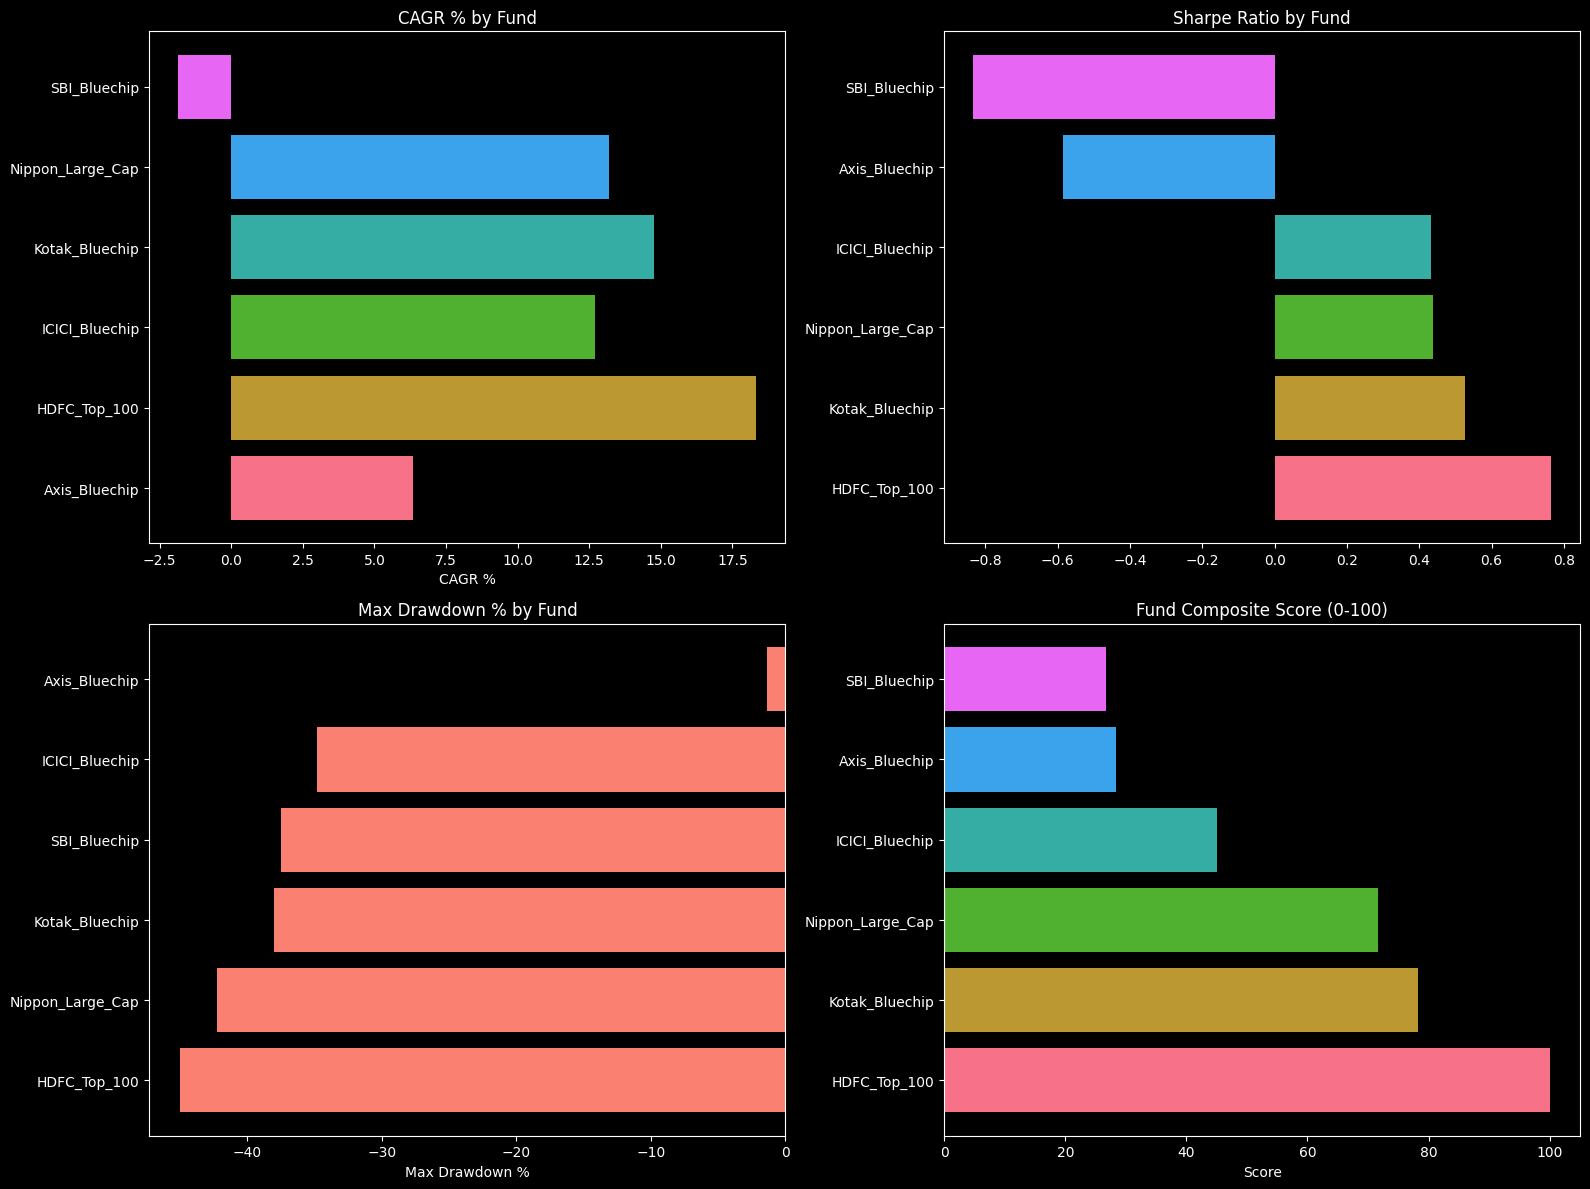

✅ Performance charts saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: CAGR comparison
axes[0,0].barh(cagr_df["Fund"], cagr_df["CAGR_%"],
               color=sns.color_palette("husl", len(cagr_df)))
axes[0,0].set_title("CAGR % by Fund")
axes[0,0].set_xlabel("CAGR %")

# Chart 2: Sharpe Ratio
axes[0,1].barh(sharpe_df["Fund"], sharpe_df["Sharpe_Ratio"],
               color=sns.color_palette("husl", len(sharpe_df)))
axes[0,1].set_title("Sharpe Ratio by Fund")

# Chart 3: Max Drawdown
axes[1,0].barh(dd_df["Fund"], dd_df["Max_Drawdown_%"],
               color="salmon")
axes[1,0].set_title("Max Drawdown % by Fund")
axes[1,0].set_xlabel("Max Drawdown %")

# Chart 4: Fund Scorecard
axes[1,1].barh(scorecard["Fund"], scorecard["Score"],
               color=sns.color_palette("husl", len(scorecard)))
axes[1,1].set_title("Fund Composite Score (0-100)")
axes[1,1].set_xlabel("Score")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "day4_performance_metrics.png", dpi=150)
plt.show()
print("✅ Performance charts saved!")

In [11]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / "data" / "processed"

bench = pd.read_csv(PROC_DIR / "clean_benchmark_indices.csv")
print(bench.columns.tolist())
print(bench.dtypes)
print(bench.head(5))

['date', 'index_name', 'close_value']
date               str
index_name         str
close_value    float64
dtype: object
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [12]:
# Sortino Ratio
def compute_sortino(series, rf=0.065/252):
    excess = series - rf
    downside = series[series < 0]
    downside_std = downside.std() * (252 ** 0.5)
    if downside_std == 0:
        return None
    return round((excess.mean() * 252) / downside_std, 4)

sortino_results = []
for col in returns.columns:
    sortino_results.append({
        "Fund": col,
        "Sortino_Ratio": compute_sortino(returns[col].dropna())
    })

sortino_df = pd.DataFrame(sortino_results)
print(sortino_df.sort_values("Sortino_Ratio", ascending=False))
sortino_df.to_csv(PROC_DIR / "sortino_ratios.csv", index=False)
print("✅ Sortino saved!")

               Fund  Sortino_Ratio
1      HDFC_Top_100         0.9260
3    Kotak_Bluechip         0.6248
4  Nippon_Large_Cap         0.5320
2    ICICI_Bluechip         0.5316
0     Axis_Bluechip        -0.3241
5      SBI_Bluechip        -0.4884
✅ Sortino saved!


In [13]:
# Alpha & Beta using Nifty 100
bench["date"] = pd.to_datetime(bench["date"])
nifty100 = bench[bench["index_name"] == "NIFTY100"].set_index("date")["close_value"]
bench_ret = nifty100.pct_change().dropna()

from scipy import stats

ab_results = []
for col in returns.columns:
    fund_ret = returns[col].dropna()
    common = fund_ret.index.intersection(bench_ret.index)
    if len(common) < 30:
        continue
    f = fund_ret.loc[common]
    b = bench_ret.loc[common]
    slope, intercept, _, _, _ = stats.linregress(b, f)
    ab_results.append({
        "Fund": col,
        "Alpha": round(intercept * 252, 4),
        "Beta": round(slope, 4)
    })

ab_df = pd.DataFrame(ab_results)
print(ab_df)
ab_df.to_csv(PROC_DIR / "alpha_beta.csv", index=False)
print("✅ Alpha & Beta saved!")

               Fund   Alpha    Beta
0     Axis_Bluechip  0.0662 -0.0003
1      HDFC_Top_100  0.0956  0.0077
2    ICICI_Bluechip  0.0415  0.0018
3    Kotak_Bluechip  0.1433  0.0351
4  Nippon_Large_Cap  0.1274 -0.0115
5      SBI_Bluechip -0.0330 -0.0009
✅ Alpha & Beta saved!


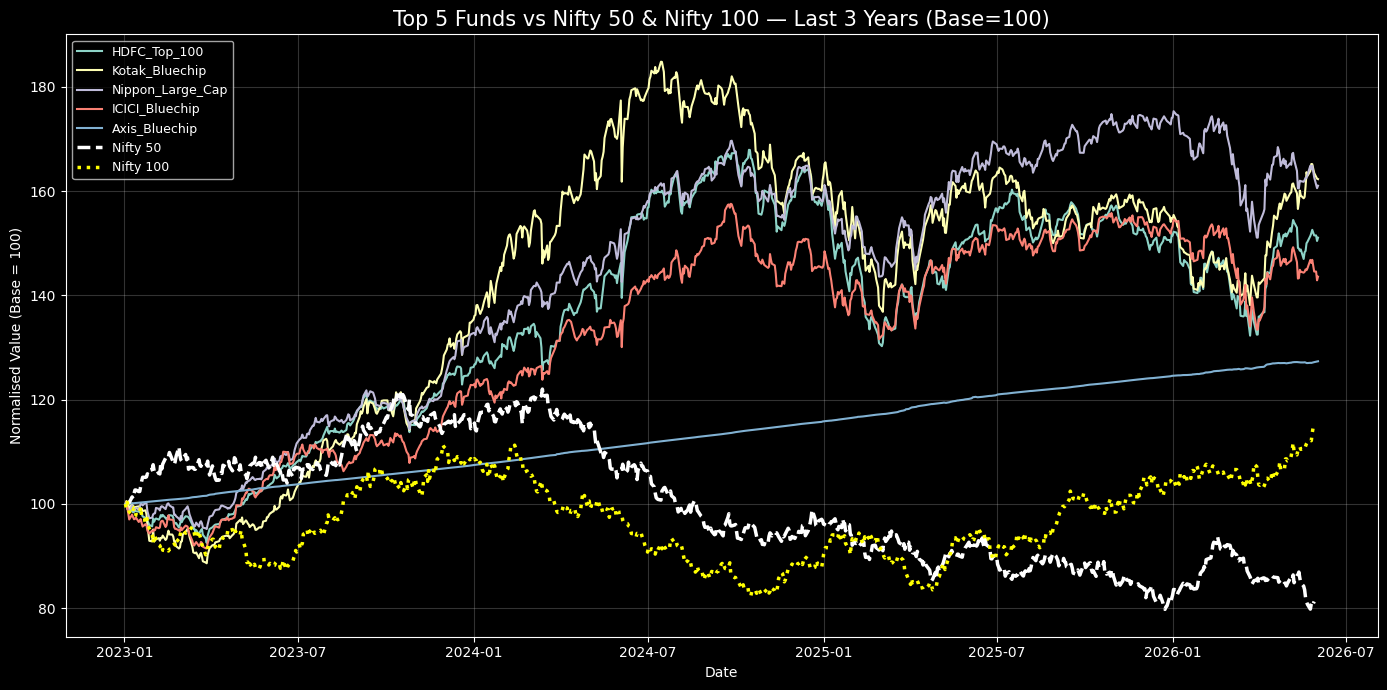

✅ Benchmark chart saved!


In [16]:
# Benchmark Comparison Chart - Last 3 years only
from datetime import datetime, timedelta

cutoff = pd.Timestamp("2023-01-01")  # 3 year window

top5 = scorecard.head(5)["Fund"].tolist()

nifty50 = bench[bench["index_name"] == "NIFTY50"].set_index("date")["close_value"]
nifty100 = bench[bench["index_name"] == "NIFTY100"].set_index("date")["close_value"]

# Filter to last 3 years
nifty50 = nifty50[nifty50.index >= cutoff]
nifty100 = nifty100[nifty100.index >= cutoff]

def normalise(series):
    series = series[series.index >= cutoff].dropna()
    return (series / series.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))

for col in top5:
    if col in combined.columns:
        s = combined[col].dropna()
        s = s[s.index >= cutoff]
        if len(s) > 0:
            ax.plot((s / s.iloc[0]) * 100, label=col, linewidth=1.5)

ax.plot(normalise(nifty50), label="Nifty 50", linewidth=2.5,
        linestyle="--", color="white")
ax.plot(normalise(nifty100), label="Nifty 100", linewidth=2.5,
        linestyle=":", color="yellow")

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 — Last 3 Years (Base=100)", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Value (Base = 100)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "benchmark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Benchmark chart saved!")

In [15]:
# Tracking Error
tracking_errors = []
for col in top5:
    if col in returns.columns:
        common = returns[col].dropna().index.intersection(bench_ret.index)
        if len(common) < 30:
            continue
        diff = returns[col].loc[common] - bench_ret.loc[common]
        te = diff.std() * (252 ** 0.5)
        tracking_errors.append({"Fund": col, "Tracking_Error_%": round(te * 100, 2)})

te_df = pd.DataFrame(tracking_errors)
print(te_df)
te_df.to_csv(PROC_DIR / "tracking_error.csv", index=False)
print("✅ Tracking Error saved!")

               Fund  Tracking_Error_%
0      HDFC_Top_100             18.79
1    Kotak_Bluechip             21.74
2  Nippon_Large_Cap             19.09
3    ICICI_Bluechip             19.20
4     Axis_Bluechip             12.92
✅ Tracking Error saved!
